In [14]:
from own_implementation import * 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
from scipy import stats
from scipy.stats import chi2_contingency, kstest 

In [17]:
def python_random(n):
    return [random.random() for _ in range(n)]

def numpy_random(n):
    rng = np.random.default_rng()
    return rng.uniform(0, 1, n)

def system_random(n):
    sys_random = random.SystemRandom()
    return [sys_random.random() for _ in range(n)]


In [23]:
### Generators preparation
n = 10000

generators = {
    "LCG": lambda: LCG(1664525, 1013904223, 2**32, seed=42, n=n), 
    "Python Random": lambda: python_random(n=n), ## Python's built-in random module (Mersenne Twister)
    "Numpy Random": lambda: numpy_random(n=n),   ## Numpy's random module (PCG64)
    "System Random": lambda: system_random(n=n)  ## System's random module (kryptographic)
}

data_samples = {name: gen() for name, gen in generators.items()}
for name, data in data_samples.items():
    print(f"{name}: wygenerowane {len(data)} liczb losowych")


LCG: wygenerowane 10000 liczb losowych
Python Random: wygenerowane 10000 liczb losowych
Numpy Random: wygenerowane 10000 liczb losowych
System Random: wygenerowane 10000 liczb losowych


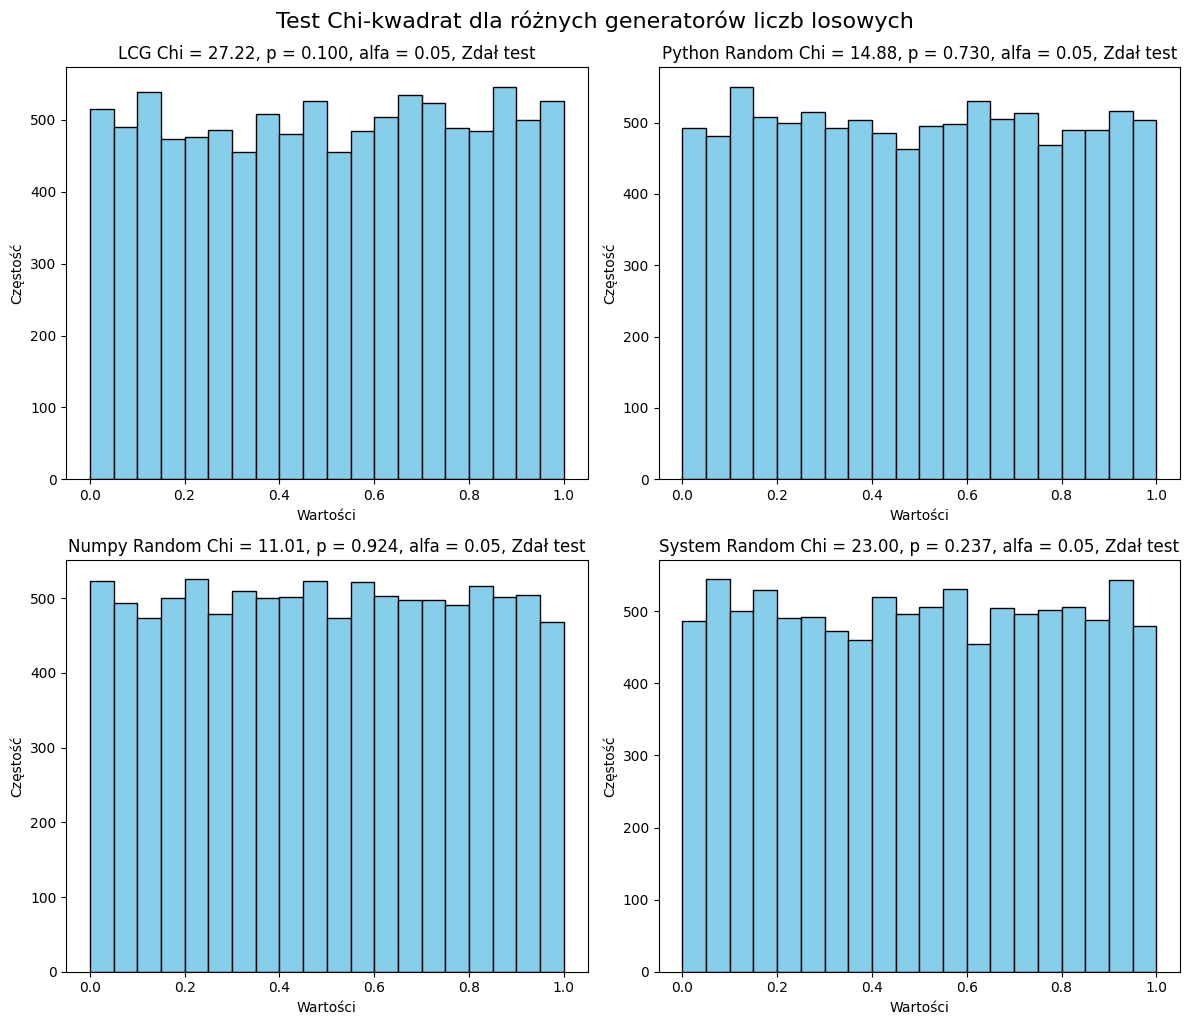

In [22]:
### Chi Square Test 
bins = 20
alpha = 0.05
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(data_samples.items()):
    chi2_stat, p_val = chi_square_test(data, bins=bins)
    result = "Zdał test" if p_val > alpha else "Nie zdał testu"

    axes[idx].hist(data, bins=bins, edgecolor='black', color='skyblue')
    axes[idx].set_title(f"{name} Chi = {chi2_stat:.2f}, p = {p_val:.3f}, alfa = {alpha}, {result}")
    axes[idx].set_xlabel("Wartości")
    axes[idx].set_ylabel("Częstość")

plt.tight_layout()
plt.suptitle("Test Chi-kwadrat dla różnych generatorów liczb losowych", fontsize=16, y=1.02)
plt.show()

In [2]:
# assert len(lcg_numbers) == n, "Błąd: Nieprawidłowa liczba wygenerowanych liczb."
# assert all(0 <= x < 1 for x in lcg_numbers), "Błąd: Liczby nie są w zakresie (0, 1)."

# # sprawdzenie równomierności rozkładu
# max_range = 100  # liczba przedziałów dla testu chi-kwadrat
# observed, _ = np.histogram(lcg_numbers, bins=max_range, range=(0, 1))
# expected = np.full(max_range, n / max_range)
# chi2, p = stats.chisquare(observed, expected)
# print(f"Test chi-kwadrat: chi2 = {chi2:.2f}, p-value = {p:.4f}")
# assert p > 0.05, "Błąd: Rozkład nie jest równomierny (p-value < 0.05)."

In [3]:
# autocorr = np.corrcoef(lcg_numbers[:-1], lcg_numbers[1:])[0, 1]
# print(f"Autokorelacja: {autocorr:.4f}")
# assert abs(autocorr) < 0.1, "Błąd: Wysoka autokorelacja między kolejnymi liczbami."

In [4]:
# plt.figure(figsize=(12, 5))

# # histogram
# plt.subplot(1, 2, 1)
# plt.hist(lcg_numbers, bins=50, edgecolor='black')
# plt.title('Histogram rozkładu LCG')
# plt.xlabel('Wartość')
# plt.ylabel('Częstość')

# # wyk. sekwencji
# plt.subplot(1, 2, 2)
# plt.scatter(range(n), lcg_numbers, s=1)
# plt.title('Sekwencja liczb LCG')
# plt.xlabel('Indeks')
# plt.ylabel('Wartość')

# plt.tight_layout()
# plt.show()